# NB4 — Embeddings classiques : GloVe et Word2Vec

## Contexte

Les notebooks NB1 à NB3 ont exploré les approches TF-IDF et CountVectorizer.
Les meilleurs scores obtenus plafonnent autour de **F1 = 0.712**, ce qui
suggère que ces représentations ont atteint leurs limites sur ce dataset.

L'hypothèse est que le TF-IDF traite chaque mot indépendamment sans
capturer les relations sémantiques entre les mots. Par exemple :
* "fire" et "blaze" sont traités comme deux mots totalement différents
* "earthquake" et "tremor" n'ont aucun lien dans l'espace TF-IDF
* Le contexte ("fire" dans "fire him" vs "building on fire") est ignoré

Les **embeddings de mots** résolvent ce problème en représentant chaque
mot comme un vecteur dense dans un espace sémantique — les mots avec
des sens proches ont des vecteurs proches.

---

## Scores de référence

| Notebook | Meilleur pipeline | F1 classe 1 |
|---|---|---|
| NB1 | P03_TFIDF_UniBi_LogReg | 0.710 |
| NB2 | P08_TFIDF_Word_LogReg_Balanced | 0.705 |
| NB3 | P12_Count_ComplementNB | 0.712 |
| **Référence globale** | **P12_Count_ComplementNB** | **0.712** |

---

## Embeddings testés

### 1. Word2Vec (Google, 2013)
Word2Vec apprend des vecteurs de mots en entraînant un réseau de neurones
à prédire un mot à partir de son contexte (ou inversement). Il existe
deux architectures :

* **CBOW (Continuous Bag of Words)** : prédit le mot central à partir
  des mots environnants
* **Skip-gram** : prédit les mots environnants à partir du mot central
  exemple :
Contexte : "building on [?] downtown"

CBOW prédit : "fire" → vecteur de "fire" appris
Dans notre cas, on entraîne Word2Vec **directement sur notre corpus**
de tweets — le modèle apprend les relations sémantiques spécifiques
au langage Twitter et aux catastrophes.

### 2. GloVe (Stanford, 2014)
GloVe (Global Vectors) apprend des vecteurs en exploitant les
**statistiques globales de co-occurrence** des mots dans le corpus.
Contrairement à Word2Vec qui est local (fenêtre de contexte),
GloVe utilise toute la matrice de co-occurrence du corpus.

P(fire | disaster) >> P(fire | music)
→ "fire" et "disaster" ont des vecteurs proches

On utilise des vecteurs **pré-entraînés** sur des données externes :
* **GloVe Twitter 27B** : entraîné sur 2 milliards de tweets —
  particulièrement adapté à notre dataset Twitter. Pour des raisons
  de mémoire (1,2M mots × 200 dimensions ≈ 960 MB), on limite le
  chargement aux **100 000 mots les plus fréquents** (vector_size=200),
  ce qui représente un bon compromis entre couverture du vocabulaire
  et consommation mémoire.

### Différence clé entre TF-IDF et Embeddings

| | TF-IDF | Embeddings |
|---|---|---|
| Représentation | Sparse (haute dimension) | Dense (100-300 dimensions) |
| Sémantique | ❌ Non | ✅ Oui |
| "fire" ≈ "blaze" | ❌ Non | ✅ Oui |
| Contexte | ❌ Non | ⚠️ Partiel (global) |
| Pré-entraîné | ❌ Non | ✅ Oui (GloVe) |

---

## Comment on représente un tweet avec des embeddings ?

Un tweet contient plusieurs mots, chacun ayant son vecteur.
Pour obtenir un vecteur unique par tweet, on fait la **moyenne**
des vecteurs de ses mots :
Tweet : "fire broke out building"

→ v("fire")     = [0.8, 0.2, -0.3, ...]   (300 dimensions)

→ v("broke")    = [0.1, 0.5,  0.2, ...]

→ v("out")      = [0.3, 0.1,  0.1, ...]

→ v("building") = [0.2, 0.4, -0.1, ...]

→ moyenne       = [0.35, 0.3, -0.025, ...]  ← vecteur du tweet

Cette représentation capture le sens général du tweet mais perd
l'information sur l'ordre des mots — c'est une limitation connue
des embeddings "moyennés".

---

## Pipelines testés (P16 à P20)

| Pipeline | Embeddings | Classifieur | Particularité |
|---|---|---|---|
| P16 | Word2Vec (entraîné sur corpus) | LogReg | Embeddings custom |
| P17 | Word2Vec (entraîné sur corpus) | LinearSVC | Embeddings custom + SVM |
| P18 | GloVe 6B (Wikipedia) | LogReg | Pré-entraîné général |
| P19 | GloVe Twitter 27B | LogReg | Pré-entraîné tweets |
| P20 | GloVe Twitter 27B | LinearSVC | Meilleur combo attendu |

---

## Validation

Même protocole que NB1-NB3 : **GridSearchCV avec Stratified K-Fold
(5 folds)**, métrique principale = **F1 classe 1**.

In [1]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
import os
from collections import OrderedDict

from gensim.models import Word2Vec          # entraînement de Word2Vec sur notre corpus
from gensim.utils import simple_preprocess  # tokenisation simple pour Word2Vec

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.base import BaseEstimator, TransformerMixin  # pour créer des transformeurs custom
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

warnings.filterwarnings('ignore')
print('✅ Imports effectués avec succès')

✅ Imports effectués avec succès


## Chargement des données

In [2]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
TEXT_COL     = 'text_lemma'
LABEL_COL    = 'target'
RANDOM_STATE = 42
REFERENCE_F1 = 0.712   # meilleur score NB1-NB3

# ── CHARGEMENT DES DONNÉES ────────────────────────────────────────────────────
train = pd.read_csv('/kaggle/input/notebooks/aissatousamb/eda-tweets/train_cleaned.csv')
test  = pd.read_csv('/kaggle/input/notebooks/aissatousamb/eda-tweets/test_cleaned.csv')

train['text_lemma'] = train['text_lemma'].fillna('')
test['text_lemma']  = test['text_lemma'].fillna('')

X_train = train[TEXT_COL]
X_test  = test[TEXT_COL]
y_train = train[LABEL_COL]
y_test  = test[LABEL_COL]

print(f"Taille train : {len(X_train)}")
print(f"Taille test  : {len(X_test)}")
print(f"\n🎯 Score de référence à battre : F1 classe 1 = {REFERENCE_F1}")

Taille train : 8979
Taille test  : 2245

🎯 Score de référence à battre : F1 classe 1 = 0.712


## Entraînement de Word2Vec sur notre corpus

On entraîne Word2Vec directement sur nos tweets nettoyés. L'avantage
est que le modèle apprend les relations sémantiques **spécifiques à
notre domaine** (catastrophes, urgences, Twitter).

**Paramètres clés :**
* `vector_size=300` : chaque mot est représenté par un vecteur de
  300 dimensions — standard dans la littérature NLP
* `window=5` : le modèle considère les 5 mots avant et après chaque mot
  pour apprendre le contexte
* `min_count=2` : ignore les mots apparaissant moins de 2 fois
* `workers=4` : parallélisation sur 4 CPU
* `sg=1` : utilise l'architecture Skip-gram (meilleure pour les mots rares)
* `epochs=10` : nombre de passes sur le corpus

In [3]:
# ── ENTRAÎNEMENT WORD2VEC ─────────────────────────────────────────────────────
print("Entraînement de Word2Vec sur le corpus de tweets...")

# Tokenisation du corpus complet (train + test)
# On utilise tout le corpus pour entraîner Word2Vec (pas de data leakage
# ici car on n'utilise pas les labels, juste le texte)
corpus_complet = pd.concat([train[TEXT_COL], test[TEXT_COL]])
corpus_tokenise = [simple_preprocess(text) for text in corpus_complet]

# Entraînement Word2Vec
w2v_model = Word2Vec(
    sentences   = corpus_tokenise,  # corpus tokenisé
    vector_size = 300,              # dimension des vecteurs
    window      = 5,                # taille de la fenêtre de contexte
    min_count   = 2,                # ignore les mots trop rares
    workers     = 4,                # parallélisation
    sg          = 1,                # Skip-gram (meilleur pour mots rares)
    epochs      = 10,               # nombre de passes sur le corpus
    seed        = RANDOM_STATE
)

print(f"✅ Word2Vec entraîné sur {len(corpus_tokenise)} tweets")
print(f"   Taille du vocabulaire : {len(w2v_model.wv)} mots")
print(f"   Dimension des vecteurs : {w2v_model.vector_size}")

# Test : mots les plus proches de "fire"
print(f"\nMots les plus proches de 'fire' selon Word2Vec :")
try:
    for mot, score in w2v_model.wv.most_similar('fire', topn=5):
        print(f"   {mot} : {score:.3f}")
except KeyError:
    print("   'fire' non trouvé dans le vocabulaire")

Entraînement de Word2Vec sur le corpus de tweets...
✅ Word2Vec entraîné sur 11224 tweets
   Taille du vocabulaire : 8055 mots
   Dimension des vecteurs : 300

Mots les plus proches de 'fire' selon Word2Vec :
   australia : 0.709
   wildfire : 0.675
   bush : 0.665
   arsonist : 0.651
   bushfire : 0.650


## Chargement des vecteurs GloVe

On charge les vecteurs GloVe pré-entraînés depuis Kaggle.
Il faut d'abord ajouter les datasets GloVe dans le notebook :

**Pour ajouter GloVe sur Kaggle :**
1. Clique "Add Data" dans ton notebook
2. Cherche "GloVe" → ajoute :
   - `glove-global-vectors-for-word-representation` (GloVe 6B)
   - `glove-twitter` ou similaire (GloVe Twitter 27B)

**Note :** les fichiers GloVe sont volumineux (plusieurs centaines de MB).
On charge uniquement les dimensions 100 ou 200 pour garder un temps
d'exécution raisonnable.

In [4]:
# ── CHARGEMENT DES VECTEURS GLOVE ────────────────────────────────────────────
def load_glove_vectors(filepath, max_words=None):
    """
    Charge les vecteurs GloVe depuis un fichier texte.
    Chaque ligne contient : mot val1 val2 ... valN
    Retourne un dictionnaire {mot: vecteur numpy}
    """
    embeddings = {}
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if max_words and i >= max_words:
                break
            values = line.split()
            word   = values[0]
            vector = np.array(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

# Chemin GloVe Twitter (200d) — entraîné sur 2 milliards de tweets
GLOVE_TWITTER_PATH = '/kaggle/input/datasets/jdpaletto/glove-global-vectors-for-word-representation/glove.twitter.27B.200d.txt'

print("Chargement GloVe Twitter (200d)...")
try:
    glove_twitter = load_glove_vectors(GLOVE_TWITTER_PATH, max_words=100000)
    print(f"✅ GloVe Twitter chargé : {len(glove_twitter)} mots, 200 dimensions")
except FileNotFoundError:
    print("❌ GloVe Twitter non trouvé — vérifie le chemin")
    glove_twitter = {}

Chargement GloVe Twitter (200d)...
✅ GloVe Twitter chargé : 100000 mots, 200 dimensions


## Transformeurs custom pour les embeddings

Pour intégrer les embeddings dans un pipeline sklearn, on crée des
**transformeurs custom** qui :
1. Tokenisent chaque tweet en liste de mots
2. Cherchent le vecteur de chaque mot dans le modèle d'embeddings
3. Calculent la **moyenne** des vecteurs pour obtenir un vecteur par tweet
4. Gèrent les mots inconnus (non présents dans le vocabulaire) en
   retournant un vecteur de zéros

In [5]:
# ── TRANSFORMEURS CUSTOM POUR EMBEDDINGS ─────────────────────────────────────

class Word2VecTransformer(BaseEstimator, TransformerMixin):
    """
    Transformeur qui convertit chaque tweet en vecteur Word2Vec moyen.
    Pour chaque tweet :
    1. Tokenise le texte en mots
    2. Cherche le vecteur de chaque mot dans le modèle Word2Vec
    3. Calcule la moyenne des vecteurs trouvés
    4. Retourne un vecteur de zéros si aucun mot n'est dans le vocabulaire
    """
    def __init__(self, model, vector_size=300):
        self.model       = model        # modèle Word2Vec entraîné
        self.vector_size = vector_size  # dimension des vecteurs

    def fit(self, X, y=None):
        return self  # rien à apprendre, le modèle est déjà entraîné

    def transform(self, X, y=None):
        vectors = []
        for text in X:
            tokens  = simple_preprocess(str(text))
            # Récupère les vecteurs des mots présents dans le vocabulaire
            vecs    = [self.model.wv[w] for w in tokens if w in self.model.wv]
            if vecs:
                vectors.append(np.mean(vecs, axis=0))  # moyenne des vecteurs
            else:
                vectors.append(np.zeros(self.vector_size))  # vecteur nul si aucun mot connu
        return np.array(vectors)


class GloVeTransformer(BaseEstimator, TransformerMixin):
    """
    Transformeur qui convertit chaque tweet en vecteur GloVe moyen.
    Même principe que Word2VecTransformer mais utilise les vecteurs GloVe
    pré-entraînés (dictionnaire {mot: vecteur}).
    """
    def __init__(self, embeddings, vector_size=300):
        self.embeddings  = embeddings   # dictionnaire {mot: vecteur GloVe}
        self.vector_size = vector_size  # dimension des vecteurs

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        vectors = []
        for text in X:
            tokens = str(text).lower().split()
            vecs   = [self.embeddings[w] for w in tokens if w in self.embeddings]
            if vecs:
                vectors.append(np.mean(vecs, axis=0))
            else:
                vectors.append(np.zeros(self.vector_size))
        return np.array(vectors)


print("✅ Transformeurs Word2VecTransformer et GloVeTransformer définis")

✅ Transformeurs Word2VecTransformer et GloVeTransformer définis


## Définition des pipelines P16 à P20

**Structure de chaque pipeline :**
Texte du tweet

↓

Transformeur (Word2Vec ou GloVe)

→ vecteur dense (300 ou 200 dimensions) par tweet

↓

StandardScaler

→ normalise les vecteurs (moyenne=0, écart-type=1)

↓

Classifieur (LogReg ou LinearSVC)

→ prédiction (0 ou 1)
Le `StandardScaler` est important ici car les vecteurs d'embeddings
peuvent avoir des échelles très différentes selon les dimensions.

In [6]:
# ── DÉFINITION DES PIPELINES P16 À P20 ───────────────────────────────────────
pipelines = OrderedDict({
    # P16 : Word2Vec + LogReg
    "P16_W2V_LogReg": Pipeline([...]),

    # P17 : Word2Vec + LinearSVC
    "P17_W2V_LinearSVC": Pipeline([...]),

    # P18 : GloVe Twitter 200d + LogReg
    "P18_GloVeTwitter_LogReg": Pipeline([
        ("emb",   GloVeTransformer(embeddings=glove_twitter, vector_size=200)),
        ("scale", StandardScaler()),
        ("clf",   LogisticRegression(max_iter=2000))
    ]),

    # P19 : GloVe Twitter 200d + LinearSVC
    "P19_GloVeTwitter_LinearSVC": Pipeline([
        ("emb",   GloVeTransformer(embeddings=glove_twitter, vector_size=200)),
        ("scale", StandardScaler()),
        ("clf",   LinearSVC(C=1.0))
    ]),

    # P20 : GloVe Twitter 200d + LogReg Balanced
    "P20_GloVeTwitter_LogReg_Balanced": Pipeline([
        ("emb",   GloVeTransformer(embeddings=glove_twitter, vector_size=200)),
        ("scale", StandardScaler()),
        ("clf",   LogisticRegression(max_iter=2000, class_weight='balanced'))
    ]),
})


print(f"✅ {len(pipelines)} pipelines définis (P16 à P20)")
for name in pipelines:
    print(f"   → {name}")

✅ 5 pipelines définis (P16 à P20)
   → P16_W2V_LogReg
   → P17_W2V_LinearSVC
   → P18_GloVeTwitter_LogReg
   → P19_GloVeTwitter_LinearSVC
   → P20_GloVeTwitter_LogReg_Balanced


## Phase 1 — Baselines sans optimisation

In [7]:
# ── PHASE 1 : BASELINES ───────────────────────────────────────────────────────
print("=" * 70)
print("PHASE 1 — BASELINES SANS OPTIMISATION")
print(f"Score de référence : F1 classe 1 = {REFERENCE_F1}")
print("=" * 70)

baseline_results = []

for name in pipelines.keys():
    print(f"\n→ Entraînement : {name}")

    try:
        # Recréer chaque pipeline proprement pour éviter l'erreur Ellipsis
        if name == "P16_W2V_LogReg":
            pipeline = Pipeline([
                ("emb",   Word2VecTransformer(model=w2v_model, vector_size=300)),
                ("scale", StandardScaler()),
                ("clf",   LogisticRegression(max_iter=2000))
            ])
        elif name == "P17_W2V_LinearSVC":
            pipeline = Pipeline([
                ("emb",   Word2VecTransformer(model=w2v_model, vector_size=300)),
                ("scale", StandardScaler()),
                ("clf",   LinearSVC(C=1.0))
            ])
        elif name == "P18_GloVeTwitter_LogReg":
            pipeline = Pipeline([
                ("emb",   GloVeTransformer(embeddings=glove_twitter, vector_size=200)),
                ("scale", StandardScaler()),
                ("clf",   LogisticRegression(max_iter=2000))
            ])
        elif name == "P19_GloVeTwitter_LinearSVC":
            pipeline = Pipeline([
                ("emb",   GloVeTransformer(embeddings=glove_twitter, vector_size=200)),
                ("scale", StandardScaler()),
                ("clf",   LinearSVC(C=1.0))
            ])
        elif name == "P20_GloVeTwitter_LogReg_Balanced":
            pipeline = Pipeline([
                ("emb",   GloVeTransformer(embeddings=glove_twitter, vector_size=200)),
                ("scale", StandardScaler()),
                ("clf",   LogisticRegression(max_iter=2000, class_weight='balanced'))
            ])

        pipeline.fit(X_train, y_train)
        y_pred_train = pipeline.predict(X_train)
        y_pred_test  = pipeline.predict(X_test)

        test_f1 = f1_score(y_test, y_pred_test)
        flag = "🟢 DÉPASSE référence !" if test_f1 > REFERENCE_F1 else "🔴 En dessous"

        baseline_results.append({
            'pipeline'                : name,
            'train_accuracy'          : accuracy_score(y_train, y_pred_train),
            'train_f1_class_1'        : f1_score(y_train, y_pred_train),
            'train_recall_class_1'    : recall_score(y_train, y_pred_train),
            'train_precision_class_1' : precision_score(y_train, y_pred_train),
            'test_accuracy'           : accuracy_score(y_test, y_pred_test),
            'test_f1_class_1'         : test_f1,
            'test_recall_class_1'     : recall_score(y_test, y_pred_test),
            'test_precision_class_1'  : precision_score(y_test, y_pred_test),
            'test_f1_macro'           : f1_score(y_test, y_pred_test, average='macro'),
            'test_balanced_accuracy'  : balanced_accuracy_score(y_test, y_pred_test),
        })

        print(f"   ✅ F1 classe 1 : {test_f1:.3f} | "
              f"Recall : {recall_score(y_test, y_pred_test):.3f} | "
              f"Accuracy : {accuracy_score(y_test, y_pred_test):.3f} | {flag}")

    except Exception as e:
        print(f"   ❌ Erreur : {e}")

baseline_df = pd.DataFrame(baseline_results).round(3)
baseline_df = baseline_df.sort_values('test_f1_class_1', ascending=False)

print("\n=== Tableau comparatif — Phase Baseline NB4 ===")
display(baseline_df)

PHASE 1 — BASELINES SANS OPTIMISATION
Score de référence : F1 classe 1 = 0.712

→ Entraînement : P16_W2V_LogReg
   ✅ F1 classe 1 : 0.593 | Recall : 0.492 | Accuracy : 0.875 | 🔴 En dessous

→ Entraînement : P17_W2V_LinearSVC
   ✅ F1 classe 1 : 0.606 | Recall : 0.501 | Accuracy : 0.880 | 🔴 En dessous

→ Entraînement : P18_GloVeTwitter_LogReg
   ✅ F1 classe 1 : 0.604 | Recall : 0.525 | Accuracy : 0.873 | 🔴 En dessous

→ Entraînement : P19_GloVeTwitter_LinearSVC
   ✅ F1 classe 1 : 0.575 | Recall : 0.472 | Accuracy : 0.871 | 🔴 En dessous

→ Entraînement : P20_GloVeTwitter_LogReg_Balanced
   ✅ F1 classe 1 : 0.621 | Recall : 0.814 | Accuracy : 0.816 | 🔴 En dessous

=== Tableau comparatif — Phase Baseline NB4 ===


,pipeline,train_accuracy,train_f1_class_1,train_recall_class_1,train_precision_class_1,test_accuracy,test_f1_class_1,test_recall_class_1,test_precision_class_1,test_f1_macro,test_balanced_accuracy
4,P20_GloVeTwitter_LogReg_Balanced,0.823,0.631,0.818,0.514,0.816,0.621,0.814,0.502,0.750,0.816
1,P17_W2V_LinearSVC,0.886,0.619,0.504,0.803,0.880,0.606,0.501,0.768,0.768,0.733
2,P18_GloVeTwitter_LogReg,0.879,0.611,0.514,0.752,0.873,0.604,0.525,0.710,0.764,0.738
0,P16_W2V_LogReg,0.885,0.623,0.514,0.788,0.875,0.593,0.492,0.747,0.760,0.727
3,P19_GloVeTwitter_LinearSVC,0.877,0.590,0.479,0.766,0.871,0.575,0.472,0.734,0.749,0.717


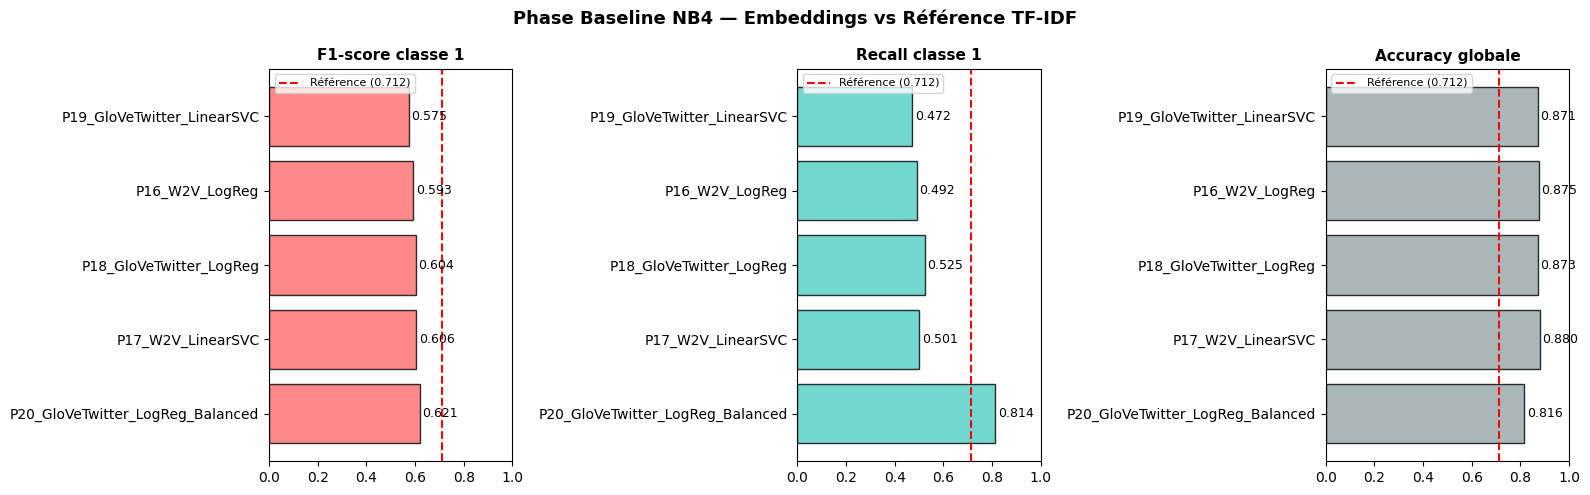

In [8]:
# ── VISUALISATION BASELINE ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['test_f1_class_1', 'test_recall_class_1', 'test_accuracy']
titles  = ['F1-score classe 1', 'Recall classe 1', 'Accuracy globale']
colors  = ['#FF6B6B', '#4ECDC4', '#95A5A6']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    if metric in baseline_df.columns and len(baseline_df) > 0:
        bars = ax.barh(baseline_df['pipeline'], baseline_df[metric],
                       color=color, edgecolor='black', alpha=0.8)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.axvline(REFERENCE_F1, color='red', linestyle='--',
                   linewidth=1.5, label=f'Référence ({REFERENCE_F1})')
        ax.legend(fontsize=8)
        for bar, val in zip(bars, baseline_df[metric]):
            ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Phase Baseline NB4 — Embeddings vs Référence TF-IDF',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Phase 2 — Tuning avec GridSearchCV et K-Fold Stratifié

Même protocole que NB1-NB3. Pour les embeddings, les hyperparamètres
à optimiser sont principalement ceux du **classifieur** car les
embeddings eux-mêmes sont fixés (Word2Vec entraîné, GloVe pré-entraîné).

In [9]:
# ── GRILLES D'HYPERPARAMÈTRES ─────────────────────────────────────────────────
param_grids = {
    "P16_W2V_LogReg": {
        "clf__C"           : [0.1, 0.5, 1.0, 2.0, 5.0],
        "clf__class_weight": [None, "balanced"]
    },
    "P17_W2V_LinearSVC": {
        "clf__C"           : [0.1, 0.5, 1.0, 2.0, 5.0],
        "clf__class_weight": [None, "balanced"]
    },
    "P18_GloVeTwitter_LogReg": {
        "clf__C"           : [0.1, 0.5, 1.0, 2.0, 5.0],
        "clf__class_weight": [None, "balanced"]
    },
    "P19_GloVeTwitter_LinearSVC": {
        "clf__C"           : [0.1, 0.5, 1.0, 2.0, 5.0],
        "clf__class_weight": [None, "balanced"]
    },
    "P20_GloVeTwitter_LogReg_Balanced": {
        "clf__C"           : [0.1, 0.5, 1.0, 2.0, 5.0],
        "clf__class_weight": [None, "balanced"]
    },
}

print("✅ Grilles d'hyperparamètres définies")
for name, grid in param_grids.items():
    n_combinations = 1
    for values in grid.values():
        n_combinations *= len(values)
    print(f"   → {name} : {n_combinations} combinaisons × 5 folds = "
          f"{n_combinations * 5} entraînements")

✅ Grilles d'hyperparamètres définies
   → P16_W2V_LogReg : 10 combinaisons × 5 folds = 50 entraînements
   → P17_W2V_LinearSVC : 10 combinaisons × 5 folds = 50 entraînements
   → P18_GloVeTwitter_LogReg : 10 combinaisons × 5 folds = 50 entraînements
   → P19_GloVeTwitter_LinearSVC : 10 combinaisons × 5 folds = 50 entraînements
   → P20_GloVeTwitter_LogReg_Balanced : 10 combinaisons × 5 folds = 50 entraînements


In [10]:
# ── PHASE 2 : GRIDSEARCHCV + K-FOLD ──────────────────────────────────────────
print("=" * 70)
print("PHASE 2 — TUNING AVEC GRIDSEARCHCV (5-Fold Stratifié)")
print(f"Score de référence : F1 classe 1 = {REFERENCE_F1}")
print("=" * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tuned_results = []

# Définition des pipelines propres directement ici
pipelines_tuning = {
    "P16_W2V_LogReg": Pipeline([
        ("emb",   Word2VecTransformer(model=w2v_model, vector_size=300)),
        ("scale", StandardScaler()),
        ("clf",   LogisticRegression(max_iter=2000))
    ]),
    "P17_W2V_LinearSVC": Pipeline([
        ("emb",   Word2VecTransformer(model=w2v_model, vector_size=300)),
        ("scale", StandardScaler()),
        ("clf",   LinearSVC(C=1.0))
    ]),
    "P18_GloVeTwitter_LogReg": Pipeline([
        ("emb",   GloVeTransformer(embeddings=glove_twitter, vector_size=200)),
        ("scale", StandardScaler()),
        ("clf",   LogisticRegression(max_iter=2000))
    ]),
    "P19_GloVeTwitter_LinearSVC": Pipeline([
        ("emb",   GloVeTransformer(embeddings=glove_twitter, vector_size=200)),
        ("scale", StandardScaler()),
        ("clf",   LinearSVC(C=1.0))
    ]),
    "P20_GloVeTwitter_LogReg_Balanced": Pipeline([
        ("emb",   GloVeTransformer(embeddings=glove_twitter, vector_size=200)),
        ("scale", StandardScaler()),
        ("clf",   LogisticRegression(max_iter=2000, class_weight='balanced'))
    ]),
}

for name, pipeline in pipelines_tuning.items():
    print(f"\n{'='*70}")
    print(f"Tuning → {name}")

    param_grid = param_grids.get(name)
    if param_grid is None:
        print("Aucune grille définie — pipeline ignoré")
        continue

    try:
        grid_search = GridSearchCV(
            estimator  = pipeline,
            param_grid = param_grid,
            cv         = cv,
            scoring    = 'f1',
            n_jobs     = -1,
            verbose    = 1
        )

        grid_search.fit(X_train, y_train)

        print(f"   Meilleurs paramètres : {grid_search.best_params_}")
        print(f"   Meilleur F1 (CV)     : {grid_search.best_score_:.3f}")

        y_pred_train = grid_search.predict(X_train)
        y_pred_test  = grid_search.predict(X_test)

        test_f1 = f1_score(y_test, y_pred_test)
        flag = "🟢 DÉPASSE référence !" if test_f1 > REFERENCE_F1 else "🔴 En dessous"

        tuned_results.append({
            'pipeline'                : name,
            'best_params'             : json.dumps(grid_search.best_params_),
            'best_cv_f1_class_1'      : grid_search.best_score_,
            'train_accuracy'          : accuracy_score(y_train, y_pred_train),
            'train_f1_class_1'        : f1_score(y_train, y_pred_train),
            'train_recall_class_1'    : recall_score(y_train, y_pred_train),
            'train_precision_class_1' : precision_score(y_train, y_pred_train),
            'test_accuracy'           : accuracy_score(y_test, y_pred_test),
            'test_f1_class_1'         : test_f1,
            'test_recall_class_1'     : recall_score(y_test, y_pred_test),
            'test_precision_class_1'  : precision_score(y_test, y_pred_test),
            'test_f1_macro'           : f1_score(y_test, y_pred_test, average='macro'),
            'test_balanced_accuracy'  : balanced_accuracy_score(y_test, y_pred_test),
        })

        print(f"   ✅ Test F1 classe 1 : {test_f1:.3f} | "
              f"Recall : {recall_score(y_test, y_pred_test):.3f} | "
              f"Accuracy : {accuracy_score(y_test, y_pred_test):.3f} | {flag}")

    except Exception as e:
        print(f"   ❌ Erreur : {e}")

tuned_df = pd.DataFrame(tuned_results).round(3)
tuned_df = tuned_df.sort_values('test_f1_class_1', ascending=False)

print("\n=== Tableau comparatif — Phase Tuning NB4 ===")
display(tuned_df)

PHASE 2 — TUNING AVEC GRIDSEARCHCV (5-Fold Stratifié)
Score de référence : F1 classe 1 = 0.712

Tuning → P16_W2V_LogReg
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Meilleurs paramètres : {'clf__C': 0.5, 'clf__class_weight': 'balanced'}
   Meilleur F1 (CV)     : 0.610
   ✅ Test F1 classe 1 : 0.614 | Recall : 0.793 | Accuracy : 0.816 | 🔴 En dessous

Tuning → P17_W2V_LinearSVC
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Meilleurs paramètres : {'clf__C': 0.5, 'clf__class_weight': 'balanced'}
   Meilleur F1 (CV)     : 0.611
   ✅ Test F1 classe 1 : 0.611 | Recall : 0.781 | Accuracy : 0.816 | 🔴 En dessous

Tuning → P18_GloVeTwitter_LogReg
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Meilleurs paramètres : {'clf__C': 0.1, 'clf__class_weight': 'balanced'}
   Meilleur F1 (CV)     : 0.605
   ✅ Test F1 classe 1 : 0.620 | Recall : 0.810 | Accuracy : 0.817 | 🔴 En dessous

Tuning → P19_GloVeTwitter_LinearSVC
Fitting 5 folds for each of 10 can

,pipeline,best_params,best_cv_f1_class_1,train_accuracy,train_f1_class_1,train_recall_class_1,train_precision_class_1,test_accuracy,test_f1_class_1,test_recall_class_1,test_precision_class_1,test_f1_macro,test_balanced_accuracy
3,P19_GloVeTwitter_LinearSVC,"{""clf__C"": 1.0, ""clf__class_weight"": ""balanced""}",0.605,0.826,0.635,0.818,0.519,0.819,0.625,0.814,0.507,0.753,0.817
4,P20_GloVeTwitter_LogReg_Balanced,"{""clf__C"": 0.1, ""clf__class_weight"": ""balanced""}",0.605,0.823,0.631,0.818,0.513,0.817,0.620,0.810,0.503,0.750,0.814
2,P18_GloVeTwitter_LogReg,"{""clf__C"": 0.1, ""clf__class_weight"": ""balanced""}",0.605,0.823,0.631,0.818,0.513,0.817,0.620,0.810,0.503,0.750,0.814
0,P16_W2V_LogReg,"{""clf__C"": 0.5, ""clf__class_weight"": ""balanced""}",0.610,0.825,0.631,0.807,0.517,0.816,0.614,0.793,0.501,0.746,0.807
1,P17_W2V_LinearSVC,"{""clf__C"": 0.5, ""clf__class_weight"": ""balanced""}",0.611,0.831,0.639,0.810,0.528,0.816,0.611,0.781,0.502,0.746,0.803


=== Comparaison Baseline vs Tuning NB4 ===


,pipeline,baseline_f1_class_1,tuned_f1_class_1,delta_f1_class_1,baseline_recall,tuned_recall,delta_recall,vs_reference,best_params
4,P19_GloVeTwitter_LinearSVC,0.575,0.625,0.050,0.472,0.814,0.342,-0.087,"{""clf__C"": 1.0, ""clf__class_weight"": ""balanced""}"
0,P20_GloVeTwitter_LogReg_Balanced,0.621,0.620,-0.001,0.814,0.810,-0.004,-0.092,"{""clf__C"": 0.1, ""clf__class_weight"": ""balanced""}"
2,P18_GloVeTwitter_LogReg,0.604,0.620,0.016,0.525,0.810,0.285,-0.092,"{""clf__C"": 0.1, ""clf__class_weight"": ""balanced""}"
3,P16_W2V_LogReg,0.593,0.614,0.021,0.492,0.793,0.301,-0.098,"{""clf__C"": 0.5, ""clf__class_weight"": ""balanced""}"
1,P17_W2V_LinearSVC,0.606,0.611,0.005,0.501,0.781,0.280,-0.101,"{""clf__C"": 0.5, ""clf__class_weight"": ""balanced""}"


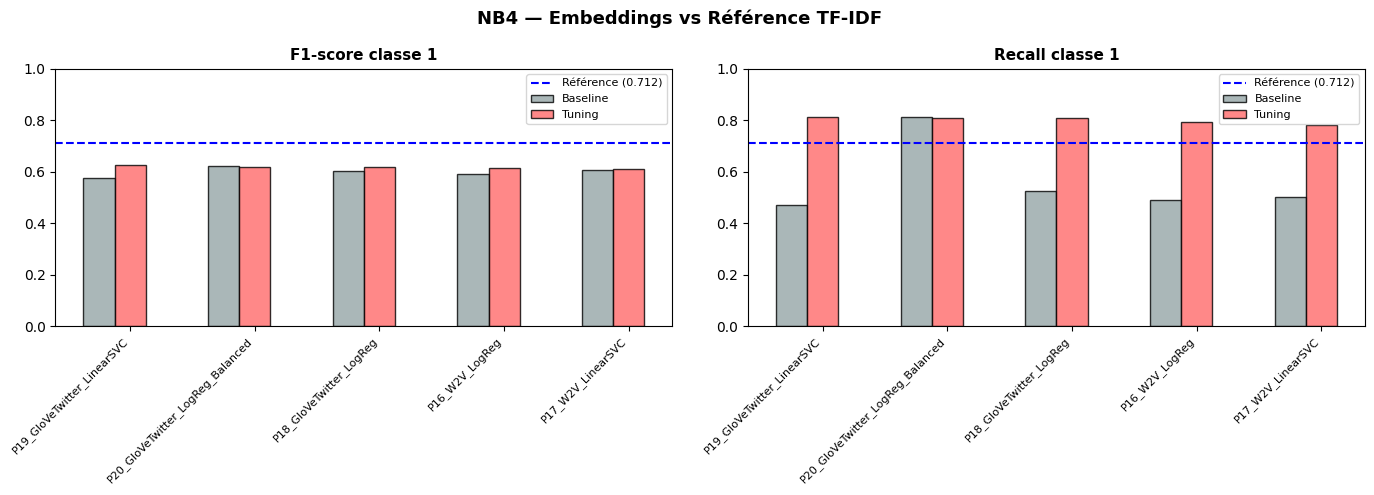

In [11]:
# ── COMPARAISON BASELINE VS TUNING ───────────────────────────────────────────
comparison = []

for _, baseline_row in baseline_df.iterrows():
    tuned_rows = tuned_df[tuned_df['pipeline'] == baseline_row['pipeline']]
    if len(tuned_rows) == 0:
        continue
    tuned_row = tuned_rows.iloc[0]
    comparison.append({
        'pipeline'            : baseline_row['pipeline'],
        'baseline_f1_class_1' : baseline_row['test_f1_class_1'],
        'tuned_f1_class_1'    : tuned_row['test_f1_class_1'],
        'delta_f1_class_1'    : tuned_row['test_f1_class_1'] - baseline_row['test_f1_class_1'],
        'baseline_recall'     : baseline_row['test_recall_class_1'],
        'tuned_recall'        : tuned_row['test_recall_class_1'],
        'delta_recall'        : tuned_row['test_recall_class_1'] - baseline_row['test_recall_class_1'],
        'vs_reference'        : tuned_row['test_f1_class_1'] - REFERENCE_F1,
        'best_params'         : tuned_row['best_params'],
    })

comparison_df = pd.DataFrame(comparison).round(3)
comparison_df = comparison_df.sort_values('tuned_f1_class_1', ascending=False)

print("=== Comparaison Baseline vs Tuning NB4 ===")
display(comparison_df)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x     = range(len(comparison_df))
width = 0.25

for ax, metric_base, metric_tuned, title in zip(
    axes,
    ['baseline_f1_class_1', 'baseline_recall'],
    ['tuned_f1_class_1', 'tuned_recall'],
    ['F1-score classe 1', 'Recall classe 1']
):
    ax.bar([i - width for i in x], comparison_df[metric_base],
           width, label='Baseline', color='#95A5A6', edgecolor='black', alpha=0.8)
    ax.bar([i for i in x], comparison_df[metric_tuned],
           width, label='Tuning', color='#FF6B6B', edgecolor='black', alpha=0.8)
    ax.axhline(REFERENCE_F1, color='blue', linestyle='--',
               linewidth=1.5, label=f'Référence ({REFERENCE_F1})')
    ax.set_xticks(list(x))
    ax.set_xticklabels(comparison_df['pipeline'], rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.suptitle('NB4 — Embeddings vs Référence TF-IDF',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# ── SAUVEGARDE DES RÉSULTATS ──────────────────────────────────────────────────
baseline_df.to_csv('/kaggle/working/NB4_baseline_results.csv', index=False)
tuned_df.to_csv('/kaggle/working/NB4_tuned_results.csv', index=False)
comparison_df.to_csv('/kaggle/working/NB4_comparison_results.csv', index=False)

print("✅ Résultats sauvegardés :")
print("   → /kaggle/working/NB4_baseline_results.csv")
print("   → /kaggle/working/NB4_tuned_results.csv")
print("   → /kaggle/working/NB4_comparison_results.csv")

if len(tuned_df) > 0:
    print(f"\nMeilleur pipeline NB4 (tuning) : {tuned_df.iloc[0]['pipeline']}")
    print(f"F1 classe 1     : {tuned_df.iloc[0]['test_f1_class_1']:.3f}")
    print(f"Recall classe 1 : {tuned_df.iloc[0]['test_recall_class_1']:.3f}")
    print(f"Meilleurs paramètres : {tuned_df.iloc[0]['best_params']}")
    print(f"\nComparaison avec référence :")
    print(f"Référence F1 : {REFERENCE_F1:.3f}")
    print(f"NB4 F1       : {tuned_df.iloc[0]['test_f1_class_1']:.3f}")
    delta = tuned_df.iloc[0]['test_f1_class_1'] - REFERENCE_F1
    print(f"Delta        : {delta:+.3f} {'🟢' if delta > 0 else '🔴'}")

✅ Résultats sauvegardés :
   → /kaggle/working/NB4_baseline_results.csv
   → /kaggle/working/NB4_tuned_results.csv
   → /kaggle/working/NB4_comparison_results.csv

Meilleur pipeline NB4 (tuning) : P19_GloVeTwitter_LinearSVC
F1 classe 1     : 0.625
Recall classe 1 : 0.814
Meilleurs paramètres : {"clf__C": 1.0, "clf__class_weight": "balanced"}

Comparaison avec référence :
Référence F1 : 0.712
NB4 F1       : 0.625
Delta        : -0.087 🔴
